In [18]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from syssimx.core.base import CoSimComponent
from syssimx.components import FMUComponent

repo_root = Path.cwd().parent.parent.parent
print(f"Repo root: {repo_root}")

sys.path.insert(0, str(repo_root))
from update_fmus import get_fmu_paths

sys.path.insert(0, str(repo_root / "demos/ControlledPendulum"))
sys.path.insert(0, str(repo_root))
from FEM.fem_pendulum import FEMPendulum
from OpenSim.opensim_pendulum import OpenSimPendulum

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Repo root: /home/flo/code/SystemSimulation


In [19]:
fem_pendulum = FEMPendulum(name="fem_pendulum")
opensim_pendulum = OpenSimPendulum(name="opensim_pendulum")

fmu_path = Path.cwd() / "FMUs/Pendulum.fmu"
eqb_pendulum = FMUComponent(name="fmu_pendulum", fmu_path=fmu_path)

t = 0.0
dt = 0.01
t_end = 1

# Initialize FEM Pendulum as Master and set EQB and OpenSim Parameters correspondingly
t0 = 0.0
fem_pendulum.anim_params.animate = False
fem_pendulum.sim_params.use_gravity = False
fem_pendulum.sim_params.with_contact = False
fem_pendulum.sim_params.t_end = t_end
fem_pendulum.initialize(t0)

q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

mass = fem_pendulum.mass
inertia = fem_pendulum.inertia
corresponding_length = np.sqrt(inertia / mass)

# Set OpenSim Parameters and initialize
opensim_pendulum.parameters["InitialConditions"]["q0"] = q0
opensim_pendulum.parameters["InitialConditions"]["omega0"] = omega0
opensim_pendulum.parameters["Model"]["mass"] = mass
opensim_pendulum.parameters["Model"]["length"] = corresponding_length
opensim_pendulum._use_gravity = fem_pendulum._use_gravity
opensim_pendulum._with_contact = fem_pendulum._with_contact
opensim_pendulum.initialize(t0)

# Set EQB Parameters and initialize
eqb_pendulum.parameters["q0"].start = q0
eqb_pendulum.parameters["omega0"].start = omega0
eqb_pendulum.parameters["m"].start = mass
eqb_pendulum.parameters["L"].start = corresponding_length
eqb_pendulum.parameters["g"].start = 0.0 if not fem_pendulum._use_gravity else 9.81
eqb_pendulum.initialize(t0)

In [20]:
plant = {"EQB": eqb_pendulum, "FEM": fem_pendulum, "OpenSim": opensim_pendulum}
mode = "FEM"

In [21]:
fem_pendulum.setup_monitoring()
fem_pendulum.display_monitoring()
fem_pendulum.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [22]:
def get_active_plant():
    return plant[mode]


def ang_position_dependent_model_selection(q: float) -> str:
    q_deg = np.rad2deg(q) % 360
    if q_deg < 2 or q_deg >= 358:
        return "FEM"
    else:
        return "EQB"


def time_dependent_model_selection(t: float) -> str:
    interval = t_end / 12
    cycle_position = int(t / interval) % 3
    if cycle_position == 0:
        return "FEM"
    elif cycle_position == 1:
        return "EQB"
    else:
        return "OpenSim"


def synch_models(current_model: CoSimComponent, new_model: CoSimComponent, t: float):
    state = current_model.get_state()
    if isinstance(new_model, FMUComponent):
        fmu_state = {
            "q0": {"value": current_model.get_state()["q"]["value"]},
            "omega0": {"value": current_model.get_state()["omega"]["value"]},
            "torque": {"value": current_model.get_state()["torque"]["value"]},
        }
        new_model.set_state(fmu_state, t)
    new_model.set_state(state, t)
    new_state = new_model.get_state()
    # Print difference betwee states
    for key in state.keys():
        diff = new_state[key]["value"] - state[key]["value"]

In [23]:
input_torque = 20  # Nm

t_vals = {"EQB": [], "FEM": [], "OpenSim": []}
torque_vals = []
alpha_vals = {"EQB": [], "FEM": [], "OpenSim": []}
omega_vals = {"EQB": [], "FEM": [], "OpenSim": []}
q_vals = {"EQB": [], "FEM": [], "OpenSim": []}

t = 0

active_plant = get_active_plant()
t_vals[mode].append(t)
alpha_vals[mode].append(0)
omega_vals[mode].append(0)
q_vals[mode].append(0)

while t < t_end:
    if t < 0.25 * t_end or t > 0.75 * t_end:
        torque = input_torque
    else:
        torque = -input_torque
    torque_vals.append(torque)
    active_plant.set_inputs({"torque": torque}, t)
    # q = active_plant.get_outputs()['q'].magnitude
    # new_mode = ang_position_dependent_model_selection(q)
    new_mode = time_dependent_model_selection(t)
    if new_mode != mode:
        new_plant = plant[new_mode]
        synch_models(active_plant, new_plant, t)
        active_plant = new_plant
        mode = new_mode

    # active_plant.set_inputs({'torque': torque}, t)

    active_plant.do_step(t, dt)
    t_next = t + dt

    res = active_plant.get_outputs()

    t_vals[mode].append(t_next)
    alpha_vals[mode].append(res["alpha"].magnitude)
    omega_vals[mode].append(res["omega"].magnitude)
    q_vals[mode].append(res["q"].magnitude)

    t = t_next

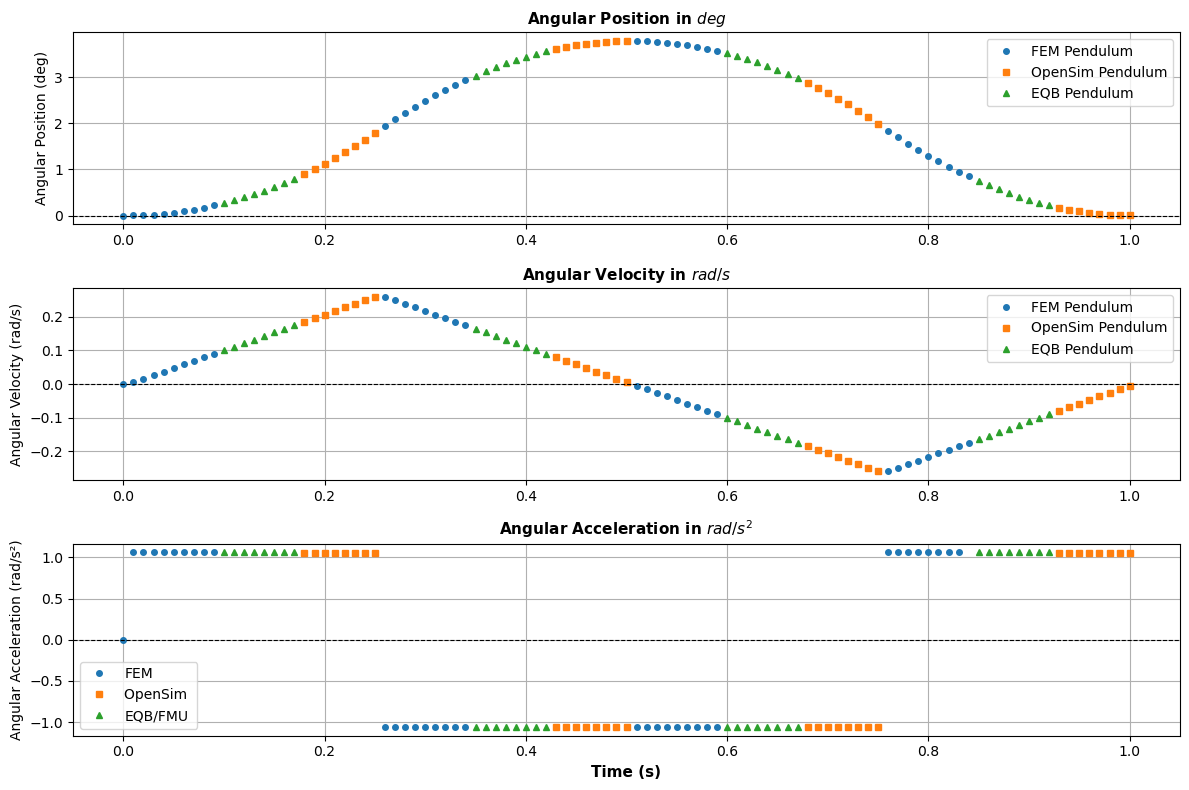

In [24]:
plt.figure(figsize=(12, 8))

marker_size = 4
fem_style = {"color": "C0", "linestyle": "None", "marker": "o", "markersize": marker_size}
opensim_style = {"color": "C1", "linestyle": "None", "marker": "s", "markersize": marker_size}
eqb_style = {"color": "C2", "linestyle": "None", "marker": "^", "markersize": marker_size}
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.subplot(3, 1, 1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals["FEM"], np.rad2deg(q_vals["FEM"]), label="FEM Pendulum", **fem_style)
plt.plot(
    t_vals["OpenSim"], np.rad2deg(q_vals["OpenSim"]), label="OpenSim Pendulum", **opensim_style
)
plt.plot(t_vals["EQB"], np.rad2deg(q_vals["EQB"]), label="EQB Pendulum", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.legend()
plt.grid(which="both")

plt.subplot(3, 1, 2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals["FEM"], omega_vals["FEM"], label="FEM Pendulum", **fem_style)
plt.plot(t_vals["OpenSim"], omega_vals["OpenSim"], label="OpenSim Pendulum", **opensim_style)
plt.plot(t_vals["EQB"], omega_vals["EQB"], label="EQB Pendulum", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.legend()
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals["FEM"][:-1], alpha_vals["FEM"][:-1], label="FEM", **fem_style)
plt.plot(t_vals["OpenSim"], alpha_vals["OpenSim"], label="OpenSim ", **opensim_style)
plt.plot(t_vals["EQB"], alpha_vals["EQB"], label="EQB/FMU", **eqb_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which="both")

plt.xlabel("Time (s)", **fontdict)
plt.legend()
plt.tight_layout()
plt.show()